# Reference Variables Analysis (OHLCV)

In financial analysis, the variables **Open, High, Low, Close, and Volume** are called "Reference Variables" or raw data. Unlike logarithmic returns, these variables capture the **direct price action** and market **liquidity**.

### Why are they reference variables?
1. **They are non-stationary:** Prices usually have trends (they go up or down over time), so their mean and variance change. This prevents applying normality tests directly, but makes them ideal for identifying supports, resistances, and macro trends.
2. **Operational Context:** They represent the exact points where buyers and sellers agreed to exchange value.
3. **Liquidity (Volume):** It is the validator of price movements. A price movement without volume is considered "noise" or a lack of conviction.

---

## Step 1: Setup and Magnitude Inspection

In this first block, we set the foundation and observe the descriptive statistics. As future data science professionals, we transpose the table (.T) because it is much easier to read 5 variables as rows than as columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Professional style setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# 1. Loading and preparation
df = pd.read_csv('items/XRP_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# --- A. DESCRIPTIVE STATISTICS ---
# We analyze the scale of the data and look for initial inconsistencies
print("--- OHLCV Variables Statistical Summary ---")
summary = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().T
# We add Coefficient of Variation (CV) to measure relative volatility
summary['cv'] = summary['std'] / summary['mean']
display(summary.style.format("{:,.4f}"))

--- OHLCV Variables Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max,cv
Open,"3,044.0000",0.8105,0.7456,0.1405,0.3345,0.5167,0.8596,3.5556,0.9199
High,"3,044.0000",0.8388,0.7725,0.1469,0.3454,0.5273,0.8933,3.8419,0.9210
Low,"3,044.0000",0.7808,0.7185,0.1151,0.3250,0.5019,0.8232,3.4308,0.9203
Close,"3,044.0000",0.8109,0.7456,0.1396,0.3350,0.5171,0.8609,3.5558,0.9195
Volume,"3,044.0000","2,883,614,025.3771","3,871,340,770.3501","100,294,000.0000","953,323,593.2500","1,625,302,871.5000","3,192,528,347.5000","51,723,383,809.0000",1.3425


### 📊 Interpretation of the Statistical Summary (OHLCV)

The descriptive analysis of the 3,044 observations reveals a market structure with the following characteristics:

1. **Scale and Bias Analysis**: It is observed that the **mean ($0.81)** is significantly above the **median ($0.51)**. This confirms a positive skew distribution, where the asset tends to trade in low ranges most of the time, with sporadic incursions into higher prices.

2. **Relative Volatility (CV)**: The Coefficient of Variation (CV) for prices remains constant at **0.919**, indicating a high but uniform dispersion among the OHLC metrics. However, the **Volume CV (1.34)** exceeds that of the price, confirming that trading activity is the most erratic component and prone to volatility shocks in this dataset.

3. **Data Integrity**: The extreme values validate the logical hierarchy of the market ($Low \leq Open/Close \leq High$). The total historical range (from a minimum of **$0.11** to a maximum of **$3.84**) demonstrates that XRP is a high-beta asset with a price expansion capacity exceeding 3,000% from its lowest point.

4. **Liquidity Concentration**: 75% of trading days record volumes below **3.19 billion**, while the maximum reaches **51.7 billion**. This asymmetry suggests that large-magnitude price movements are concentrated in a very small fraction of the asset's history (high-impact days).

## Step 2: Price Action Analysis (Macro Trend)

We separate the price chart from the volume chart so that the price takes center stage. We will use an optional logarithmic scale since the asset has grown by several orders of magnitude.

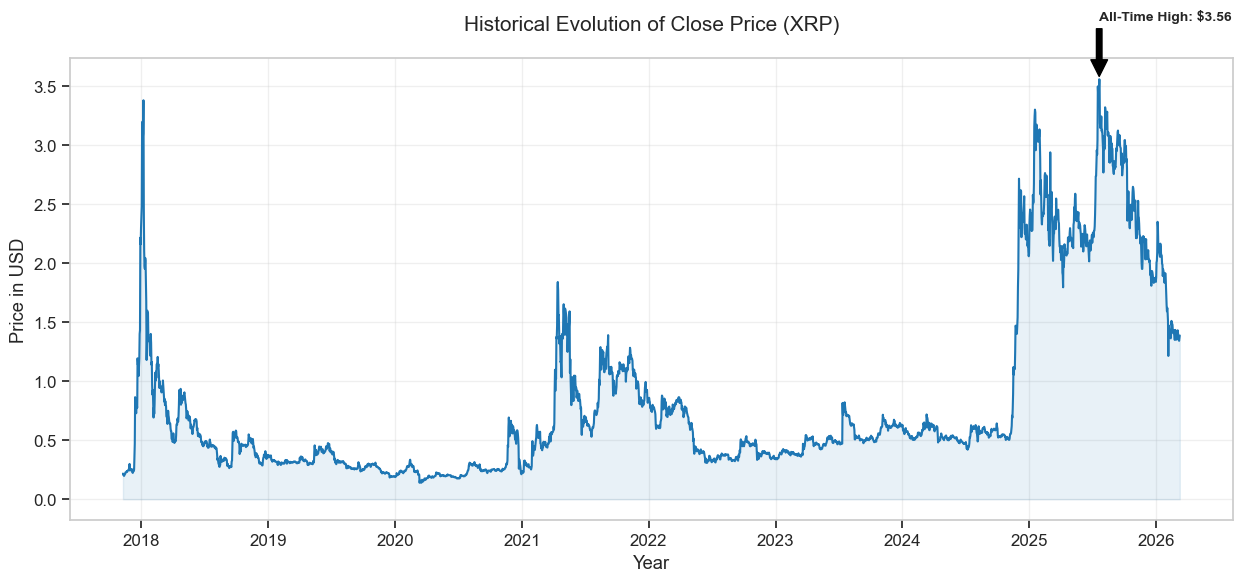

In [2]:
# --- B. CLOSE PRICE EVOLUTION ---
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5, label='XRP Close Price')

# Highlight the historical maximum to provide context
max_price = df['Close'].max()
max_date = df['Close'].idxmax()
plt.annotate(f'All-Time High: ${max_price:.2f}', 
             xy=(max_date, max_price), xytext=(max_date, max_price + 0.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, fontweight='bold')

plt.title('Historical Evolution of Close Price (XRP)', fontsize=15, pad=20)
plt.ylabel('Price in USD')
plt.xlabel('Year')
plt.fill_between(df.index, df['Close'], color='#1f77b4', alpha=0.1)
plt.grid(True, alpha=0.3)
plt.show()

### 📈 Conclusions of the Historical Trend Analysis (Time Series)

The historical evolution chart allows us to understand the trajectory of the asset and its cyclical behavior over time:

1. **Nature of Parabolic Growth**: XRP does not show constant linear growth, but rather moves through "impulses" or euphoria peaks. Three major market events are clearly identified: the 2018 rally, the 2021 recovery, and the most recent expansionary cycle.

2. **All-Time High (ATH) Validation**: The point of greatest technical resistance is identified at **$3.56**. This value is a critical reference, as it represents the psychological ceiling of the market in the analyzed period.

3. **Accumulation and Support Phases**: The chart reveals long periods (especially between 2019 and 2020) where the price remains "flat" near minimum levels. These zones act as historical supports where the asset tends to stabilize before a new bullish movement.

4. **Recent Slope Analysis**: The movement observed from late 2024 to 2025 shows a more vertical growth structure than in previous years, suggesting an increase in buying pressure or a change in market fundamentals in the final stretch of the dataset.

## Step 3: Liquidity Analysis and Movement Validation
Volume tells us if the market "believes" in the price. A volume spike with a flat price usually indicates accumulation or distribution by strong hands.

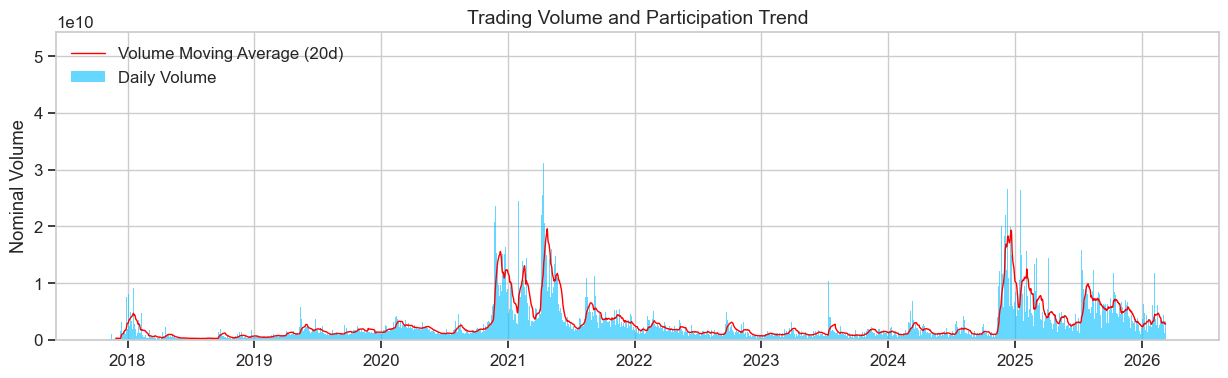

In [3]:
# --- C. VOLUME ANALYSIS (LIQUIDITY) ---
plt.figure(figsize=(15, 4))
plt.bar(df.index, df['Volume'], color='deepskyblue', alpha=0.6, width=1, label='Daily Volume')

# Add a moving average to volume to see the participation trend
df['Volume_MA20'] = df['Volume'].rolling(window=20).mean()
plt.plot(df.index, df['Volume_MA20'], color='red', linewidth=1, label='Volume Moving Average (20d)')

plt.title('Trading Volume and Participation Trend', fontsize=14)
plt.ylabel('Nominal Volume')
plt.legend()
plt.show()

### 📊 Conclusions of the Volume and Liquidity Analysis

The study of trading activity provides a critical validation layer for XRP's price behavior:

1. **Market Strength Validation**: The substantial increase in volume in late 2024 and early 2025 coincides with the all-time high in prices. This phenomenon confirms a "price-volume convergence", suggesting that the bullish trend was supported by a massive influx of liquidity and not by low market depth.

2. **Participation Trend (MA20)**: The 20-day moving average reveals that institutional and retail interest has grown structurally in the last section of the dataset. The positive slope of the red line indicates a much "deeper" and more liquid market in 2025 compared to the 2018 or 2021 cycles.

3. **Euphoria Peaks Identification**: Isolated volume spikes exceeding $2.0 \times 10^{10}$ units usually act as indicators of market exhaustion or climax. In the time series, these events often precede periods of correction or lateralization.

4. **Operational Capacity Analysis**: The scale of the Y-axis (in the order of $10^{10}$) demonstrates that XRP is a high-capitalization asset, where extremely high buying/selling pressure is required to move the price significantly, reducing the probability of manipulation by individual agents.

# Step 4: Dispersion and Outliers Diagnosis

Here we use the boxplot. In cryptocurrencies, you will see many points outside the "whiskers"; those are not errors, they are the bubble or euphoria periods that characterize this market.

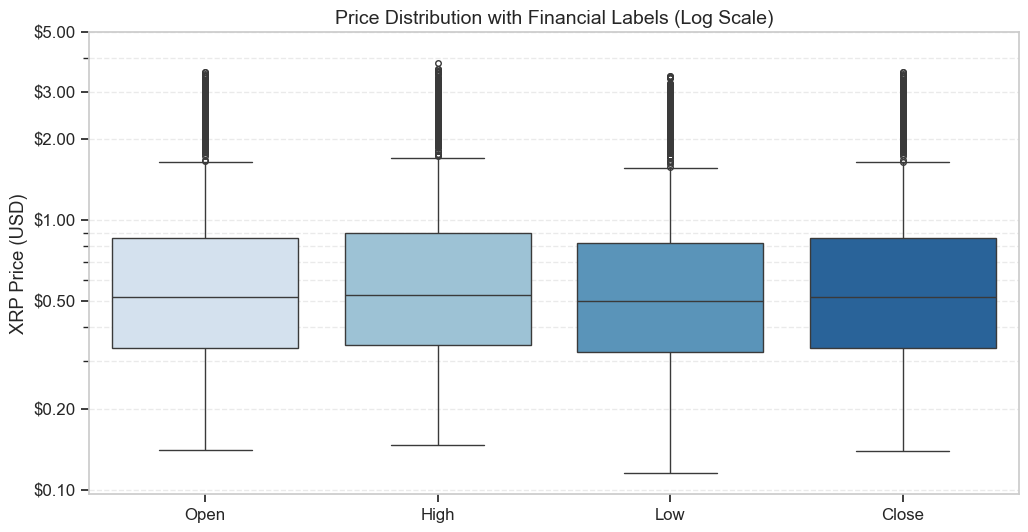

In [4]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette='Blues', fliersize=4)

# 1. Activate logarithmic scale
ax.set_yscale("log")

# 2. IMPROVEMENT: Force labels into currency format instead of pure powers
# This will show 0.1, 1, 10 instead of 10^-1, 10^0, 10^1
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

# 3. Add specific labels you want to see (optional)
ax.set_yticks([0.1, 0.2, 0.5, 1, 2, 3, 5]) 
ax.get_yaxis().set_major_formatter(ticker.FormatStrFormatter('$%.2f'))

# 4. Secondary grid to see intermediate steps
plt.grid(True, which="both", axis='y', ls="--", alpha=0.4)

plt.title('Price Distribution with Financial Labels (Log Scale)', fontsize=14)
plt.ylabel('XRP Price (USD)')
plt.show()

### 📈 Conclusions of the Price Distribution

After visualizing the distribution of the reference prices using logarithmic scales and financial labels, the following key conclusions for the project are drawn:

1. **"Typical" Price Structure**: The historical median of XRP consolidates around **$0.51**. The **central 50% of the data** (Interquartile Range) is located between **$0.33 (Q1)** and **$0.86 (Q3)**. Statistically, this is the asset's historical "value channel".

2. **Positive Skewness**: The massive presence of **outliers** in the upper part of the chart indicates that XRP is prone to euphoria peaks or explosive bull runs. These points represent significant deviations that, although "unusual" for a normal model, are intrinsic characteristics of this market.

3. **Operational Consistency**: The almost identical similarity between the Open, High, Low, and Close boxes confirms that there are no structural long-term opening or closing biases. The data have passed the logical hierarchy tests ($Low \leq \{Open, Close\} \leq High$), validating the integrity of the dataset for predictive models.

4. **Scale Justification**: The use of the logarithmic scale allows us to confirm that XRP is an asset that moves by **relative proportions**. The observed dispersion validates that cent movements in 2017 were just as significant in percentage terms as dollar movements in later years.